# Introduction
This colab worksheet provides a starting point for Task 2 (the computer vision task).

# Data Loading

In [1]:
# Download the data stored in a zipped numpy array from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.

!wget "https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5" -O face_alignment_training_images.npz

# The test images (without points)
!wget "https://sussex.box.com/shared/static/8n5ofhb9so0ia85g4bbcmnt3h6z53m9a" -O face_alignment_test_images.npz

--2025-05-14 22:05:22--  https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-05-14 22:05:22--  https://sussex.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-05-14 22:05:22--  https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting resp

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [2]:
def confirm_checksum(filename, true_checksum):
  import subprocess
  checksum = subprocess.check_output(['shasum',filename]).decode('utf-8')
  print (checksum)
  assert checksum.split(' ')[0] == true_checksum, 'Checksum does not match for ' + filename + ' redownload the data.'

confirm_checksum('face_alignment_training_images.npz', 'affc56216e34c827f10681a14c602981c06ddeb3')
confirm_checksum('face_alignment_test_images.npz', 'e480535442512b8175ae110d2d3e507378cabbdb')



affc56216e34c827f10681a14c602981c06ddeb3  face_alignment_training_images.npz

e480535442512b8175ae110d2d3e507378cabbdb  face_alignment_test_images.npz



# Load the data

In [3]:
import numpy as np


# Load the data using np.load
data = np.load('face_alignment_training_images.npz', allow_pickle=True)

# Extract the images
images = data['images']
# and the data points
pts = data['points']

print(images.shape, pts.shape)

test_data = np.load('face_alignment_test_images.npz', allow_pickle=True)
test_images = test_data['images']
print(test_images.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

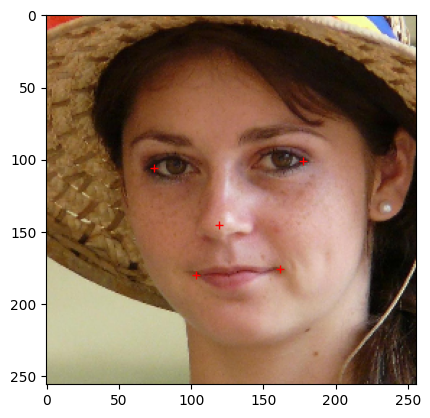

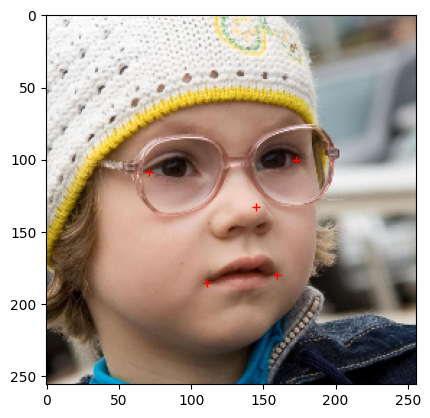

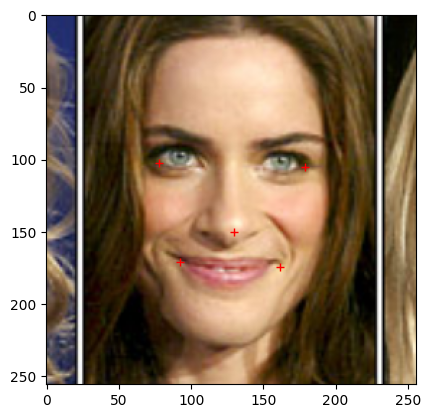

In [4]:

def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+r')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images.shape[0])
  visualise_pts(images[idx, ...], pts[idx, ...])

# Calculating Prediction Error and exporting results

In [5]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [6]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')


Epoch 1, Loss: 630.4821
Validation Loss: 38.9471
Epoch 2, Loss: 34.9669
Validation Loss: 42.9198
Epoch 3, Loss: 32.8276
Validation Loss: 27.5347
Epoch 4, Loss: 28.2210
Validation Loss: 25.4819
Epoch 5, Loss: 26.7564
Validation Loss: 30.9722
Epoch 6, Loss: 25.8094
Validation Loss: 46.5968
Epoch 7, Loss: 22.7548
Validation Loss: 18.1246
Epoch 8, Loss: 16.1235
Validation Loss: 16.4579
Epoch 9, Loss: 14.1176
Validation Loss: 20.9433
Epoch 10, Loss: 13.0123
Validation Loss: 12.4762
Saved predictions to results_task2.csv


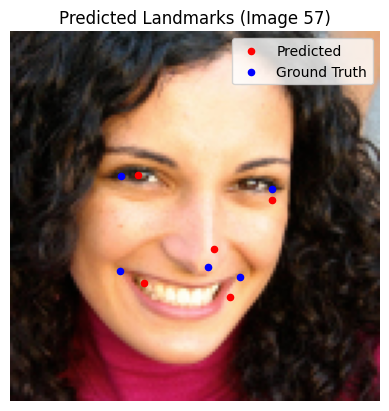

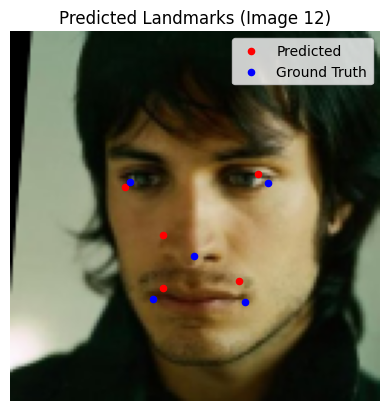

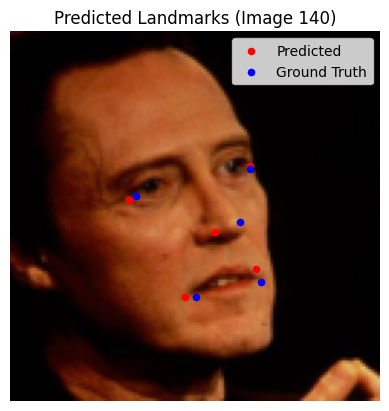

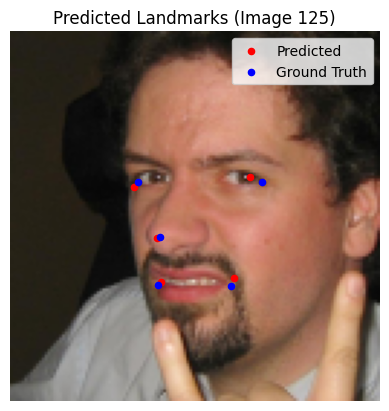

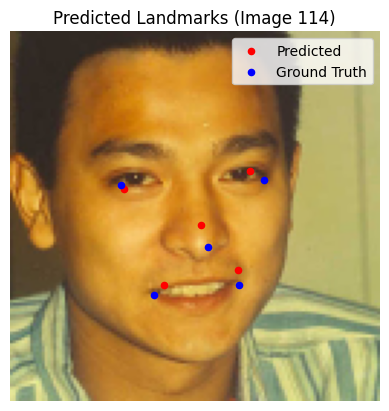

In [7]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class FaceDataset(Dataset):
    def __init__(self, images, landmarks, transform=None):
        self.images = images
        self.landmarks = landmarks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        pts = self.landmarks[idx]

        img_resized = cv2.resize(img, (128, 128)) / 255.0
        pts_rescaled = pts * [128 / img.shape[1], 128 / img.shape[0]]

        img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2, 0, 1)
        pts_tensor = torch.tensor(pts_rescaled.flatten(), dtype=torch.float32)

        return img_tensor, pts_tensor


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 10)  # 5 points * (x, y)
        )

    def forward(self, x):
        x = self.features(x)
        return self.regressor(x)


def train_model(model, dataloader, val_loader, epochs=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {epoch_loss / len(dataloader):.4f}")

        # Validation Loss
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_loss += criterion(outputs, labels).item()
            print(f"Validation Loss: {val_loss / len(val_loader):.4f}")

    return model


def predict_test(model, test_images):
    model.eval()
    preds = []
    for img in test_images:
        img_resized = cv2.resize(img, (128, 128)) / 255.0
        img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
        with torch.no_grad():
            output = model(img_tensor).cpu().numpy().reshape(-1, 2)
        output *= [img.shape[1] / 128, img.shape[0] / 128]
        preds.append(output)
    return np.array(preds)


def visualize_predictions(test_images, predicted_points, num=5):
    for i in range(num):
        idx = np.random.randint(0, len(test_images))
        img = test_images[idx]
        pred_pts = predicted_points[idx]
        plt.imshow(img)
        plt.scatter(pred_pts[:, 0], pred_pts[:, 1], c='r')
        plt.title(f'Predicted Landmarks (Image {idx})')
        plt.show()

def visualize_comparison(img, pred_pts, true_pts):
    plt.imshow(img)
    plt.plot(pred_pts[:, 0], pred_pts[:, 1], 'xr', label='Prediction')
    plt.plot(true_pts[:, 0], true_pts[:, 1], 'og', label='Ground Truth')
    plt.legend()
    plt.title("Prediction vs Ground Truth")
    plt.show()

def cumulative_error_plot(errors):
    sorted_errs = np.sort(errors)
    cumulative = np.linspace(0, 1, len(sorted_errs))
    plt.plot(sorted_errs, cumulative)
    plt.xlabel("Normalized RMSE")
    plt.ylabel("Cumulative Proportion")
    plt.title("Cumulative Error Distribution")
    plt.grid(True)
    plt.show()

def boxplot_errors(errors, title="Boxplot of Landmark Prediction Errors"):
    plt.boxplot(errors)
    plt.title(title)
    plt.ylabel("Normalized RMSE")
    plt.grid(True)
    plt.show()

def compute_normalized_rmse(pred_pts, gt_pts):
    pred_pts = np.reshape(pred_pts, (-1, 5, 2))
    gt_pts = np.reshape(gt_pts, (-1, 5, 2))
    interocular_dist = np.linalg.norm(gt_pts[:, 0] - gt_pts[:, 1], axis=1)
    rmse = np.sqrt(np.mean((pred_pts - gt_pts) ** 2, axis=(1, 2)))
    return rmse / interocular_dist


train_data = np.load('face_alignment_training_images.npz', allow_pickle=True)
test_data = np.load('face_alignment_test_images.npz', allow_pickle=True)
images, points = train_data['images'], train_data['points']
test_images = test_data['images']

full_dataset = FaceDataset(images, points)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)

model = SimpleCNN()
model = train_model(model, train_dl, val_dl, epochs=10)

val_imgs = []
val_preds = []
val_gts = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_dl:
        outputs = model(imgs).cpu().numpy().reshape(-1, 5, 2)
        labels = labels.cpu().numpy().reshape(-1, 5, 2)
        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
        val_imgs.append(imgs)
        val_preds.append(outputs)
        val_gts.append(labels)

val_imgs = np.vstack(val_imgs)
val_preds = np.vstack(val_preds)
val_gts = np.vstack(val_gts)

predicted_points = predict_test(model, test_images)

save_as_csv(predicted_points)
print("Saved predictions to results_task2.csv")

def visualize_cnn_comparison(imgs, preds, gts, num=5):
    import random
    indices = random.sample(range(len(imgs)), num)
    for idx in indices:
        plt.imshow((imgs[idx] * 255).astype(np.uint8))
        plt.scatter(preds[idx][:, 0], preds[idx][:, 1], c='red', label='Predicted', s=20)
        plt.scatter(gts[idx][:, 0], gts[idx][:, 1], c='blue', label='Ground Truth', s=20)
        plt.legend()
        plt.title(f"Predicted Landmarks (Image {idx})")
        plt.axis('off')
        plt.show()
visualize_cnn_comparison(val_imgs, val_preds, val_gts, num=5)

Mean normalized RMSE: 0.06936703


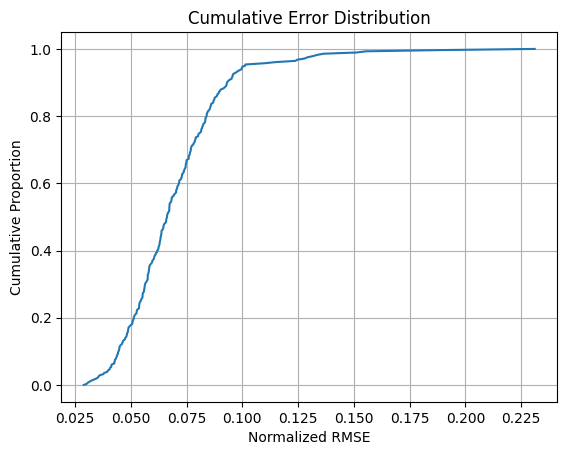

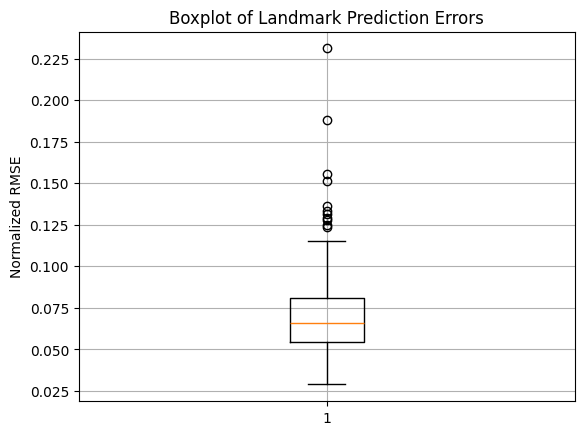

In [8]:
val_imgs = []
val_preds = []
val_gts = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_dl:
        outputs = model(imgs).cpu().numpy().reshape(-1, 5, 2)
        labels = labels.cpu().numpy().reshape(-1, 5, 2)
        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
        val_imgs.append(imgs)
        val_preds.append(outputs)
        val_gts.append(labels)

val_preds = np.vstack(val_preds)
val_gts = np.vstack(val_gts)

errors = compute_normalized_rmse(val_preds, val_gts)
print("Mean normalized RMSE:", np.mean(errors))

cumulative_error_plot(errors)
boxplot_errors(errors)

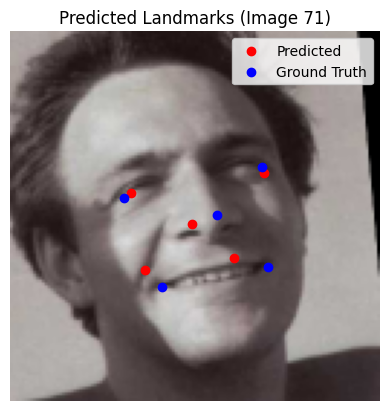

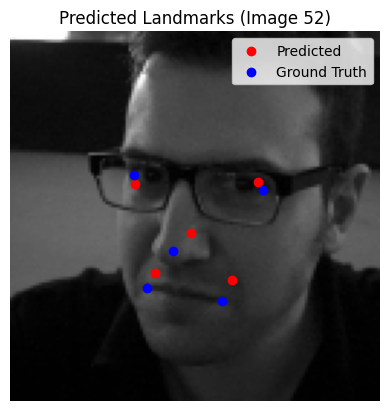

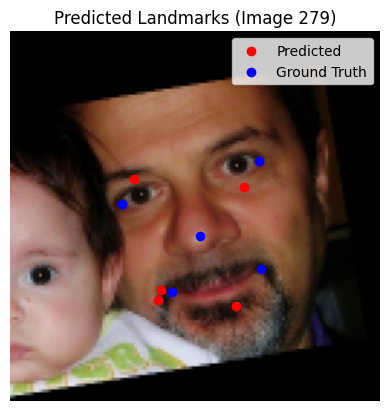

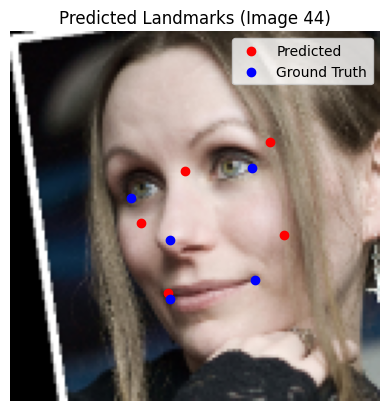

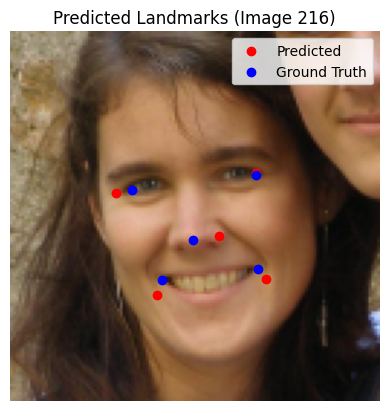

In [9]:
from sklearn.linear_model import LinearRegression

def prepare_grayscale_flattened(images):
    flattened = []
    for img in images:
        if img is None or img.size == 0:
            continue
        if img.ndim == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            gray = img
        if gray.shape[0] == 0 or gray.shape[1] == 0:
            continue
        resized = cv2.resize(gray, (64, 64)).flatten()
        flattened.append(resized)
    return np.array(flattened) / 255.0

def unpack_if_batched(image_list):
    if isinstance(image_list[0], np.ndarray) and image_list[0].ndim == 4:
        return list(image_list[0])
    return image_list

train_images_all = []
train_pts_all = []
for imgs, labels in train_dl:
    imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
    labels = labels.cpu().numpy().reshape(-1, 5, 2)
    train_images_all.extend(imgs)
    train_pts_all.extend(labels)

train_imgs = np.array(train_images_all)
train_pts = np.array(train_pts_all)
original_h, original_w = train_imgs[0].shape[:2]
train_pts[:, :, 0] *= 64 / original_w
train_pts[:, :, 1] *= 64 / original_h

train_imgs = unpack_if_batched(train_imgs)
val_imgs = unpack_if_batched(val_imgs)

def train_linear_regression(train_imgs, train_pts):
    X_train = prepare_grayscale_flattened(train_imgs)
    y_train = train_pts.reshape(len(train_pts), -1)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def predict_linear_regression(model, test_imgs):
    X_test = prepare_grayscale_flattened(test_imgs)
    if X_test.shape[0] == 0:
        raise ValueError("X_test is empty. No valid images were processed.")
    y_pred = model.predict(X_test)
    return y_pred.reshape(-1, 5, 2)

linreg_model = train_linear_regression(train_imgs, train_pts)

val_images_all = []
val_pts_all = []
for imgs, labels in val_dl:
    imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
    labels = labels.cpu().numpy().reshape(-1, 5, 2)
    val_images_all.extend(imgs)
    val_pts_all.extend(labels)
val_images_all = np.array(val_images_all)
val_pts_all = np.array(val_pts_all)

val_preds_lr = predict_linear_regression(linreg_model, val_images_all)

def visualize_predictions(images, predicted_points, ground_truth=None, num=5):
    import matplotlib.pyplot as plt
    import random

    indices = random.sample(range(len(images)), num)
    for i, idx in enumerate(indices):
        img = images[idx]
        pred_pts = predicted_points[idx]

        scale_x = img.shape[1] / 64
        scale_y = img.shape[0] / 64
        pred_pts = pred_pts.copy()
        pred_pts[:, 0] *= scale_x
        pred_pts[:, 1] *= scale_y

        plt.imshow((img * 255).astype(np.uint8))
        plt.scatter(pred_pts[:, 0], pred_pts[:, 1], c='red', label='Predicted')

        if ground_truth is not None:
            gt_pts = ground_truth[idx]
            plt.scatter(gt_pts[:, 0], gt_pts[:, 1], c='blue', label='Ground Truth')

        plt.title(f"Predicted Landmarks (Image {idx})")
        plt.axis('off')
        plt.legend()
        plt.show()

visualize_predictions(val_images_all, val_preds_lr, ground_truth=val_pts_all, num=5)


Linear Regression Mean Normalized RMSE: 0.7293237


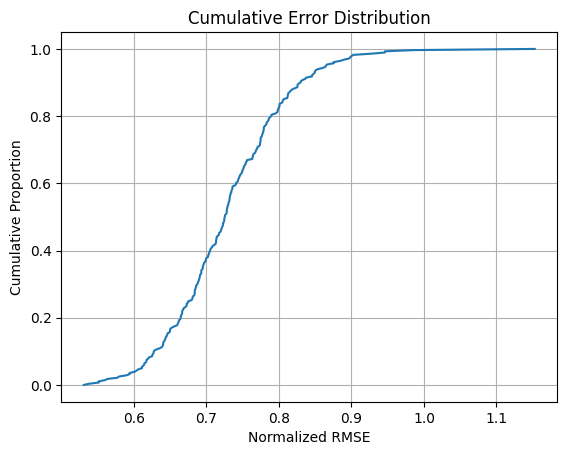

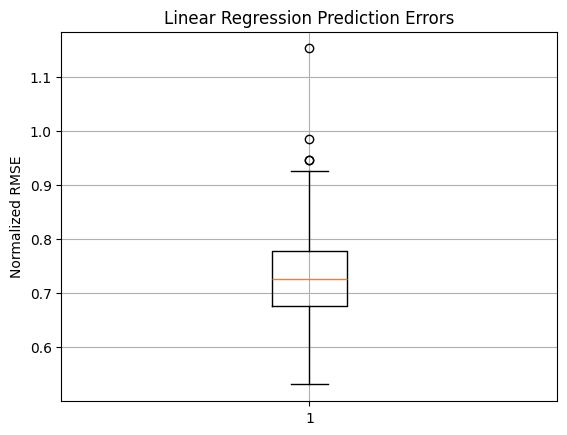

In [10]:
linreg_rmse = compute_normalized_rmse(val_preds_lr, val_pts_all)
print("Linear Regression Mean Normalized RMSE:", np.mean(linreg_rmse))

cumulative_error_plot(linreg_rmse)
plt.show()
boxplot_errors(linreg_rmse, title="Linear Regression Prediction Errors")
plt.show()

Cascaded Regressor Mean Normalized RMSE: 0.08542143


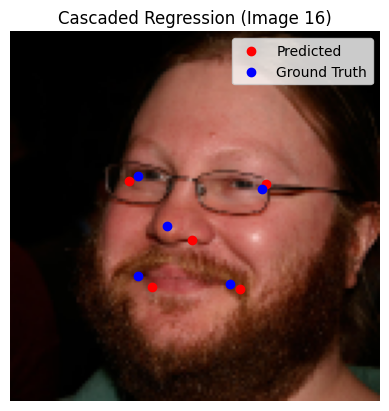

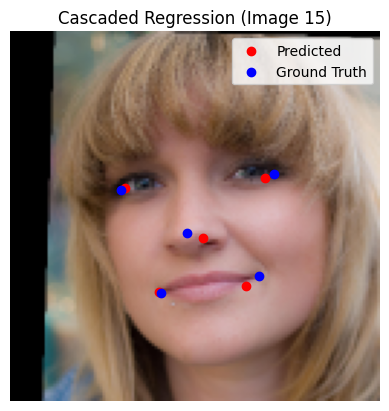

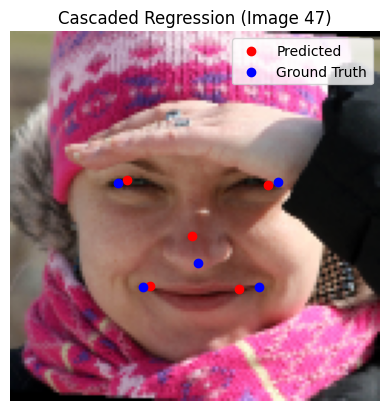

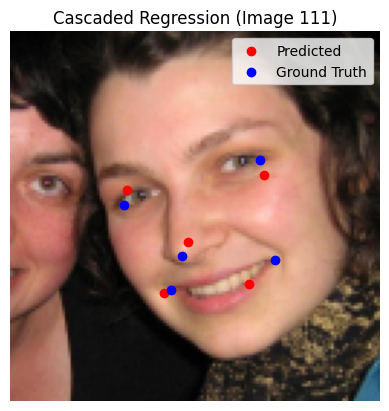

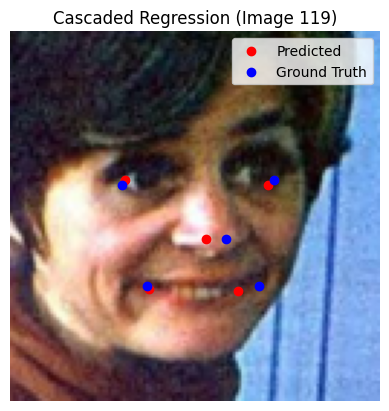

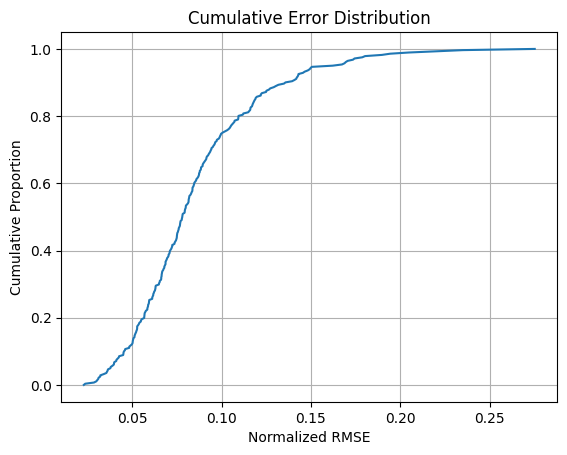

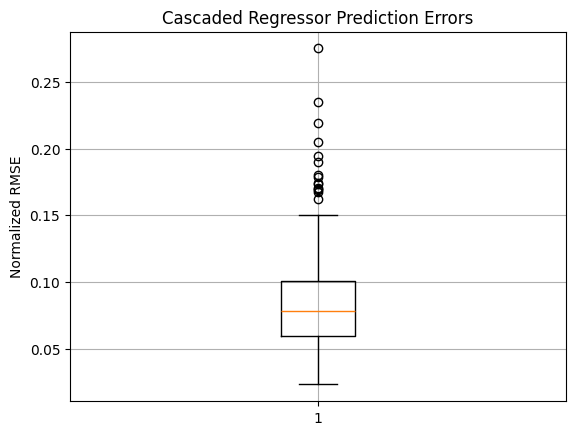

In [11]:
from sklearn.linear_model import Ridge
import numpy as np

class CascadedRegressor:
    def __init__(self, num_stages=3):
        self.num_stages = num_stages
        self.models = []
        self.mean_shape = None

    def fit(self, X, y):
        """
        X: (N, D) - flattened grayscale images
        y: (N, 10) - landmark coordinates flattened (5 points * 2)
        """
        N, D = X.shape
        current_preds = np.tile(y.mean(axis=0), (N, 1))
        self.mean_shape = y.mean(axis=0)

        for stage in range(self.num_stages):
            residual = y - current_preds
            model = Ridge(alpha=1.0)
            model.fit(X, residual)
            update = model.predict(X)
            current_preds += update
            self.models.append(model)

    def predict(self, X):
        """
        X: (N, D)
        """
        N = X.shape[0]
        current_preds = np.tile(self.mean_shape, (N, 1))

        for model in self.models:
            update = model.predict(X)
            current_preds += update

        return current_preds.reshape(-1, 5, 2)


train_images_all = []
train_pts_all = []

for imgs, labels in train_dl:
    imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
    labels = labels.cpu().numpy().reshape(-1, 5, 2)
    train_images_all.extend(imgs)
    train_pts_all.extend(labels)

train_imgs = np.array(train_images_all)
train_pts = np.array(train_pts_all)

original_h, original_w = train_imgs[0].shape[:2]
train_pts[:, :, 0] *= 64 / original_w
train_pts[:, :, 1] *= 64 / original_h
X_train = prepare_grayscale_flattened(train_imgs)
y_train = train_pts.reshape(len(train_pts), -1)

X_val_all = prepare_grayscale_flattened(val_images_all)
y_val = val_pts_all.reshape(len(val_pts_all), -1)

cascade_model = CascadedRegressor(num_stages=3)
cascade_model.fit(X_train, y_train)

val_preds_cascade = cascade_model.predict(X_val_all)

val_pts_all_normalized = val_pts_all.copy()
val_pts_all_normalized[:, :, 0] *= 64 / original_w
val_pts_all_normalized[:, :, 1] *= 64 / original_h
val_preds_cascade = val_preds_cascade[:len(val_pts_all)]
rmse_cascade = compute_normalized_rmse(val_preds_cascade, val_pts_all_normalized)
print("Cascaded Regressor Mean Normalized RMSE:", np.mean(rmse_cascade))

def visualize_predictions(images, predicted_points, ground_truth=None, num=5):
    import matplotlib.pyplot as plt
    import random

    indices = random.sample(range(len(images)), num)
    for i, idx in enumerate(indices):
        img = images[idx]
        pred_pts = predicted_points[idx]

        scale_x = img.shape[1] / 64
        scale_y = img.shape[0] / 64
        pred_pts_scaled = pred_pts.copy()
        pred_pts_scaled[:, 0] *= scale_x
        pred_pts_scaled[:, 1] *= scale_y

        plt.imshow((img * 255).astype(np.uint8))
        plt.scatter(pred_pts_scaled[:, 0], pred_pts_scaled[:, 1], c='red', label='Predicted')

        if ground_truth is not None:
            gt_pts = ground_truth[idx]
            plt.scatter(gt_pts[:, 0], gt_pts[:, 1], c='blue', label='Ground Truth')

        plt.title(f"Cascaded Regression (Image {idx})")
        plt.axis('off')
        plt.legend()
        plt.show()

visualize_predictions(val_images_all, val_preds_cascade, ground_truth=val_pts_all, num=5)

cumulative_error_plot(rmse_cascade)
boxplot_errors(rmse_cascade, title="Cascaded Regressor Prediction Errors")